#820_Pet_Cats_in_the_UK_M4_Refinement_Q3

---



**Section B Team 12**

**Kaixin Gao**

##Dataset Selection & Understanding

##Domain & Context

The Pet Cats UK dataset comes from the Movebank for Animal Tracking Data and contains high-resolution GPS tracking and metadata for domestic cats in the United Kingdom between 2013 and 2017. Cats were fitted with GPS collars, generating time-stamped location pings that capture fine-grained living habit within and beyond home environments. In addition to spatial trajectories, the dataset includes cat-level characteristics such as age, sex, neuter status, and hunting behavior.

###Motivation

Pet cats are widely distributed across urban areas, yet their living habit is often treated as homogeneous despite growing evidence of substantial individual variation. Analysis of the Pet Cats UK dataset shows that while most cats remain close to their homes, a small subset exhibits irregular living habit. Understanding these differences is important because cats’ movement behaviors directly influence ecological impacts, exposure to risk, and interactions with humans and the urban environment. By identifying distinct movement patterns among urban pet cats, this project aims to support more targeted and evidence-based decision-making for conservation groups, policymakers, and pet owners.

###Stakeholders & Decision-Makers



*   Urban planners and local councils
*   veterinarian

*   Pet owner

*  Urban biodiversity–focused conservation organizations
*   Ecologist






###Data Insights

###Data Import and Preparation

In [36]:
import pandas as pd
import numpy as np

cats_gps_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk.csv"
cats_meta_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk_reference.csv"
cats_gps = pd.read_csv(cats_gps_url)
cats_meta = pd.read_csv(cats_meta_url)

##EDA

In [37]:
print(cats_gps.info())
print(cats_meta.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18215 entries, 0 to 18214
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tag_id                    18215 non-null  object 
 1   event_id                  18215 non-null  int64  
 2   visible                   18215 non-null  bool   
 3   timestamp                 18215 non-null  object 
 4   location_long             18215 non-null  float64
 5   location_lat              18215 non-null  float64
 6   ground_speed              18215 non-null  int64  
 7   height_above_ellipsoid    18215 non-null  float64
 8   algorithm_marked_outlier  18215 non-null  bool   
 9   manually_marked_outlier   18215 non-null  bool   
 10  study_name                18215 non-null  object 
dtypes: bool(3), float64(3), int64(2), object(3)
memory usage: 1.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 colum

In [38]:
full_cats_data = cats_gps.merge(
    cats_meta,
    on='tag_id',
    how='left'
)
full_cats_data

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,study_site,age_years
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,Millie-Tag,4149497976,True,2017-11-26T15:37:52Z,-4.521489,50.869320,1260,144.66,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18211,Millie-Tag,4149497977,True,2017-11-26T15:40:59Z,-4.521498,50.869289,16380,136.60,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18212,Millie-Tag,4149497978,True,2017-11-26T16:27:31Z,-4.521803,50.869438,4500,160.97,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18213,Millie-Tag,4149497979,True,2017-11-26T16:34:26Z,-4.521946,50.869392,1044,179.81,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0


In [39]:
cleaned_cats_data = full_cats_data[~full_cats_data['tag_id'].isin(['Ares', 'Wilfred-Tag', 'Lightening Bugg-Tag', 'Jezebel-Tag','Tipsy-Tag','Maggie-Tag','Lily-Tag','Pants-Tag','Neil-Tag','Johnny-Tag','Meg-Tag','Amber-Tag','Charlie3-Tag'])]
cleaned_cats_data = cleaned_cats_data.drop('food_other', axis=1)
cleaned_cats_data

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,study_site,age_years
103,Athena,3395610893,True,2017-06-24T01:02:13Z,-5.114018,50.170296,360,78.04,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
104,Athena,3395610894,True,2017-06-24T01:05:33Z,-5.113985,50.170277,828,70.43,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
105,Athena,3395610895,True,2017-06-24T02:12:30Z,-5.114270,50.170177,288,65.66,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
106,Athena,3395610896,True,2017-06-24T02:15:29Z,-5.114331,50.170170,0,75.44,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
107,Athena,3395610897,True,2017-06-24T05:30:58Z,-5.114207,50.170303,792,68.41,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,Millie-Tag,4149497976,True,2017-11-26T15:37:52Z,-4.521489,50.869320,1260,144.66,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18211,Millie-Tag,4149497977,True,2017-11-26T15:40:59Z,-4.521498,50.869289,16380,136.60,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18212,Millie-Tag,4149497978,True,2017-11-26T16:27:31Z,-4.521803,50.869438,4500,160.97,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18213,Millie-Tag,4149497979,True,2017-11-26T16:34:26Z,-4.521946,50.869392,1044,179.81,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0


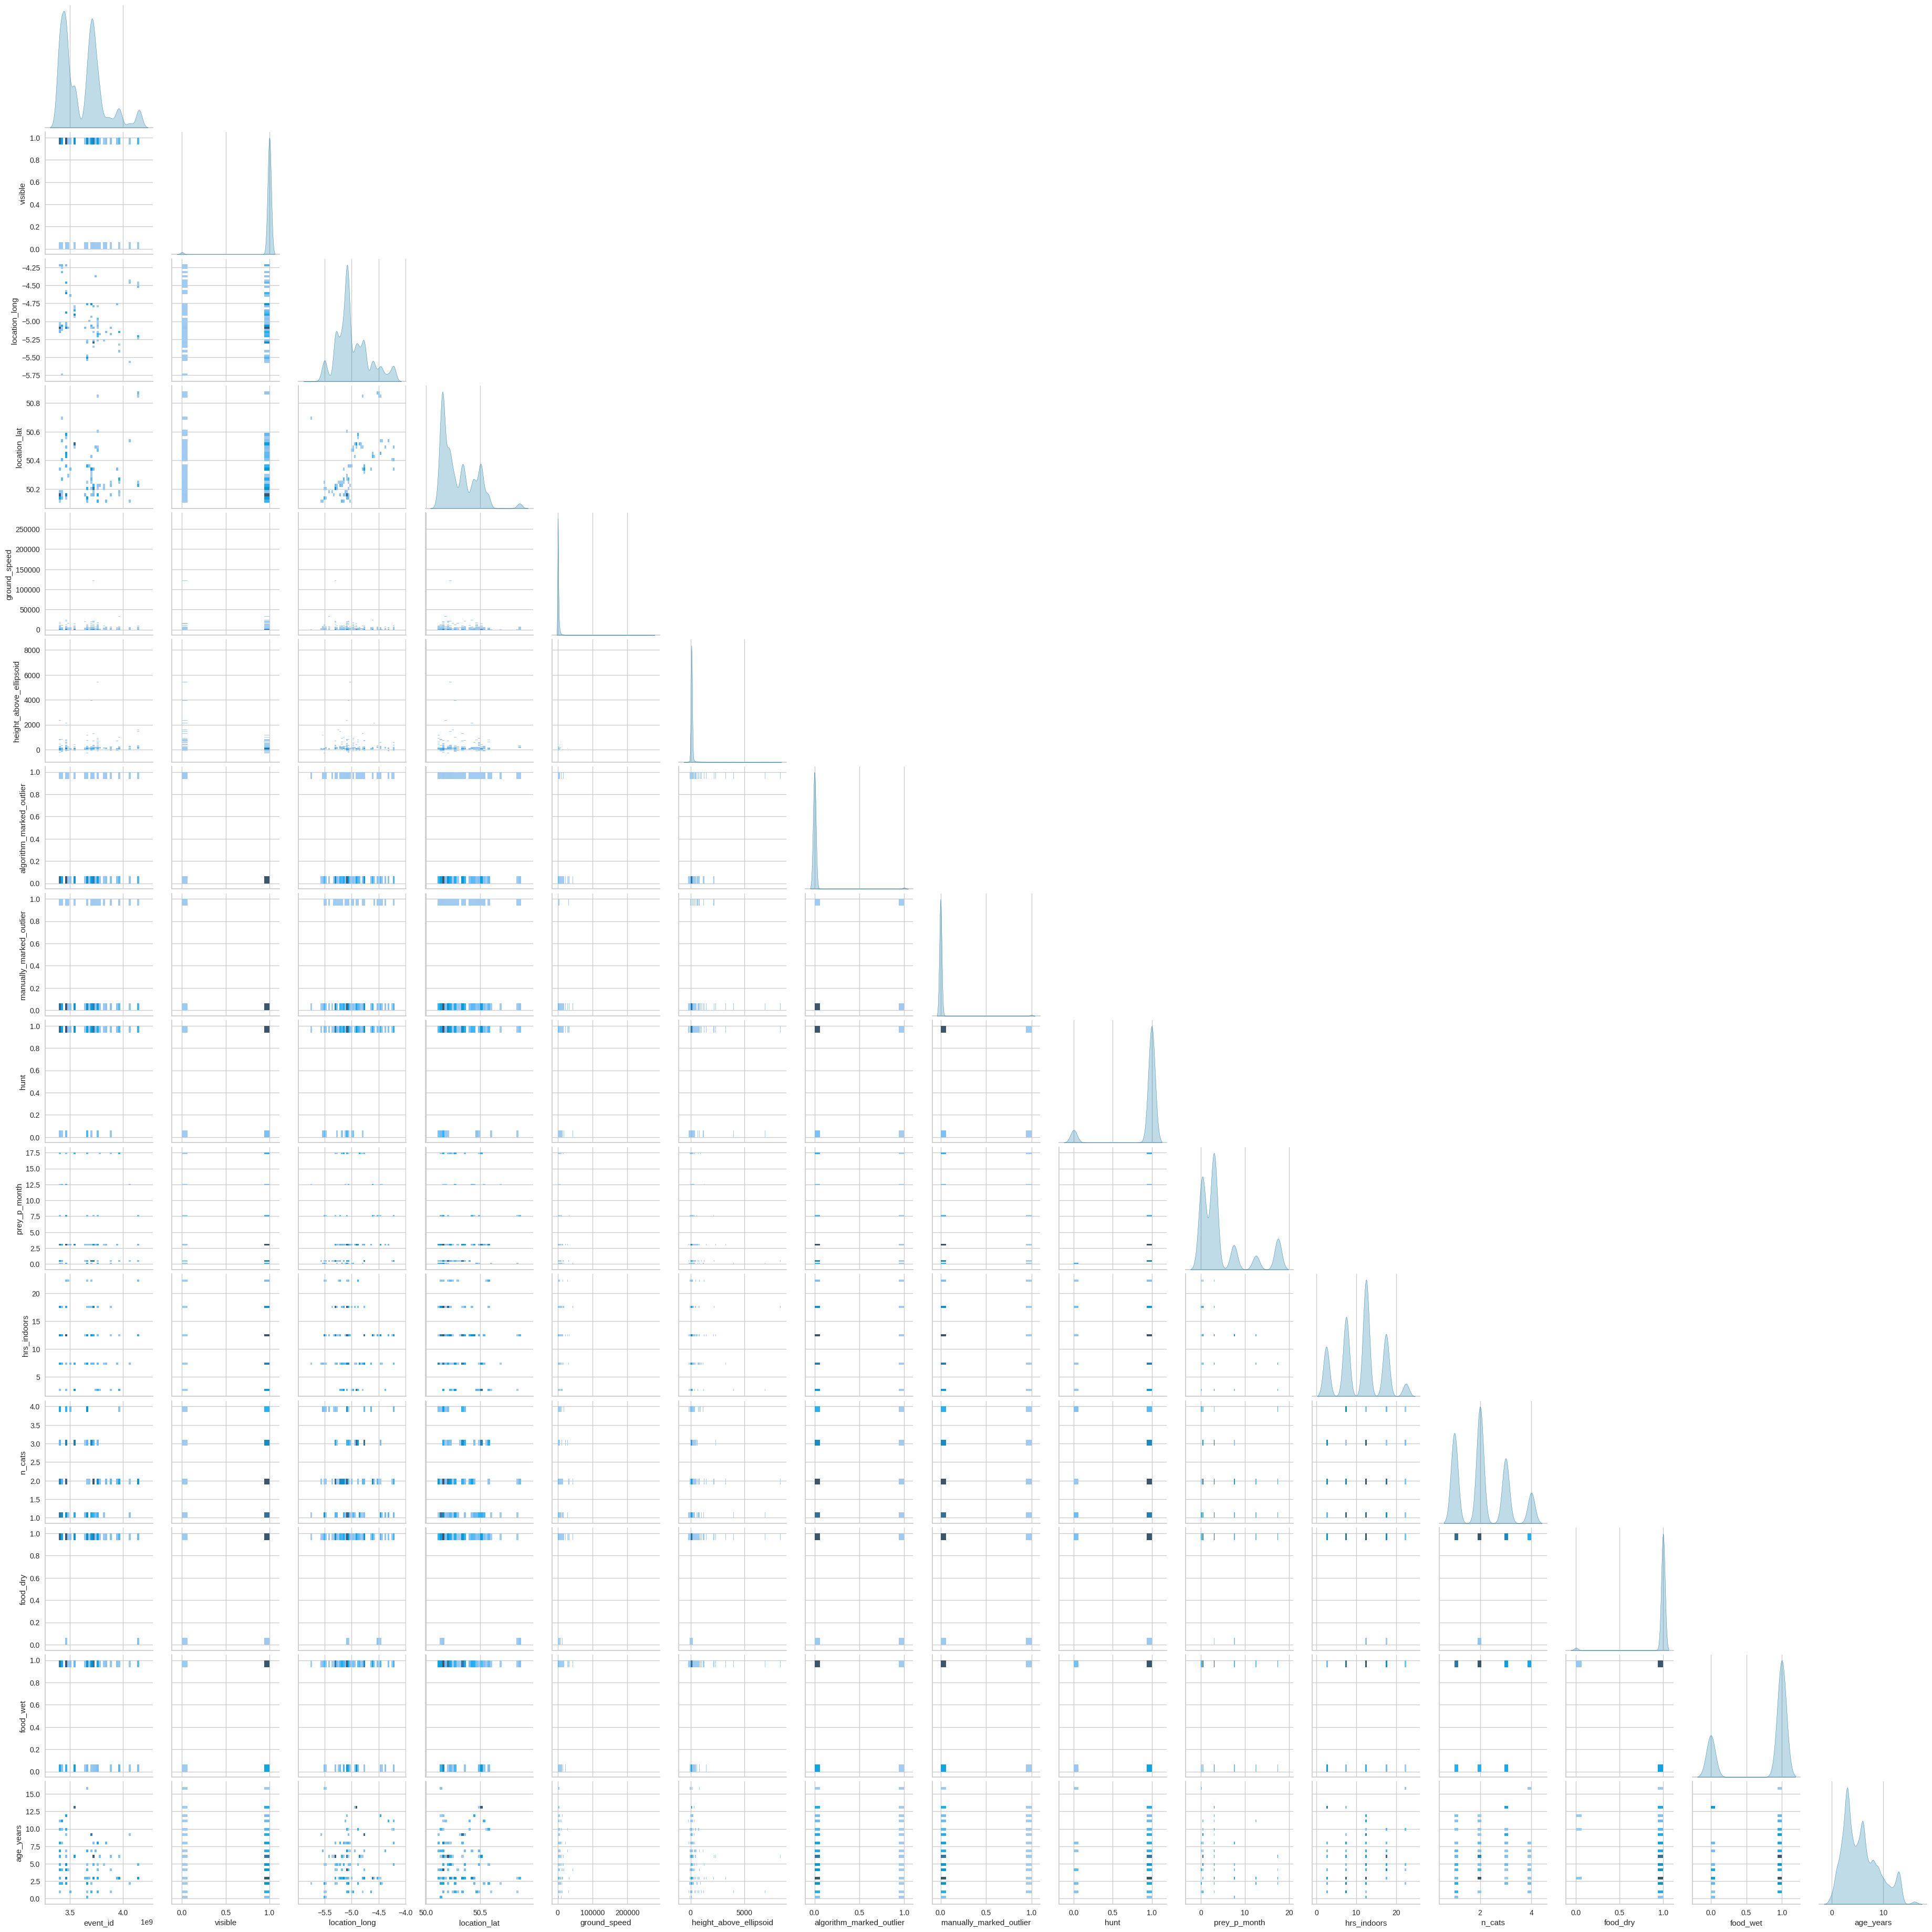

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(cleaned_cats_data, kind="hist", diag_kind="kde", corner=True)

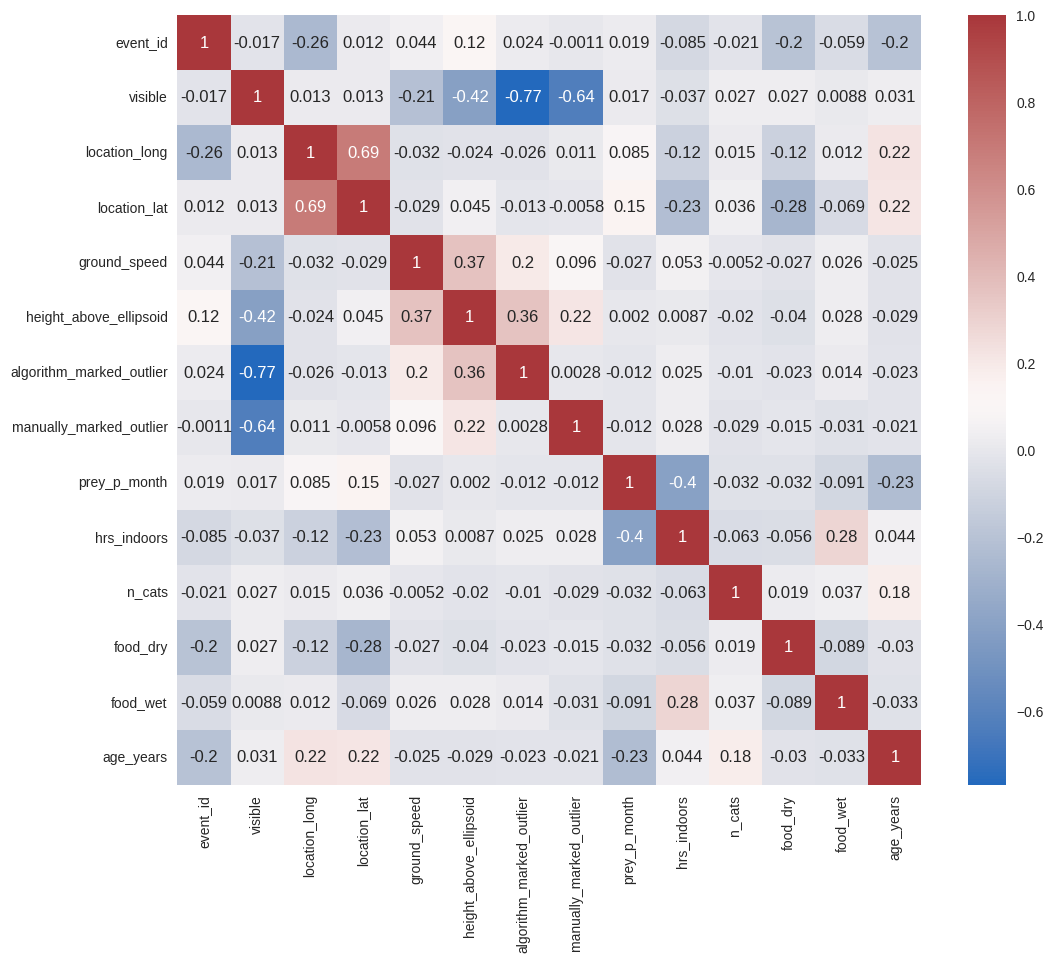

In [41]:
corr = cleaned_cats_data.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
corr = cleaned_cats_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")
plt.show()

The EDA presented above is inherited from Milestone 1 (M1). As it serves as the shared analytical foundation for all subsequent individual analyses, it has been retained without modification to ensure methodological consistency across team members’ work.

## Integrated Pipeline

In [42]:
# 1) Converts timestamps to UTC datetime and creates time-of-day indicators.
if "timestamp" in cleaned_cats_data.columns:
    cleaned_cats_data["timestamp"] = pd.to_datetime(cleaned_cats_data["timestamp"], errors="coerce", utc=True)
    cleaned_cats_data = cleaned_cats_data.dropna(subset=["timestamp"])
    cleaned_cats_data["hour"] = cleaned_cats_data["timestamp"].dt.hour
    NIGHT_HOURS = [20,21,22,23,0,1,2,3,4,5]
    cleaned_cats_data["is_night"] = cleaned_cats_data["hour"].isin(NIGHT_HOURS).astype(int)

In [43]:
# 2) Define cat-level
agg_dict = {}

for col in ["location_lat", "location_long"]:
    if col in cleaned_cats_data.columns:
        agg_dict[col] = ["mean", "std"]

if "ground_speed" in cleaned_cats_data.columns:
    cleaned_cats_data["ground_speed"] = pd.to_numeric(cleaned_cats_data["ground_speed"], errors="coerce")
    cleaned_cats_data = cleaned_cats_data.dropna(subset=["ground_speed"])
    agg_dict["ground_speed"] = ["mean", "std", "max", "median", "count"]

if "height_above_ellipsoid" in cleaned_cats_data.columns:
    agg_dict["height_above_ellipsoid"] = ["mean", "std"]

# night_ratio
if "is_night" in cleaned_cats_data.columns:
    agg_dict["is_night"] = ["mean"]

cat_level = cleaned_cats_data.groupby("tag_id").agg(agg_dict)
cat_level.columns = ["_".join([c for c in col if c]) for col in cat_level.columns]
cat_level = cat_level.reset_index()

# rename for readability
cat_level = cat_level.rename(columns={
    "ground_speed_count": "n_points",
    "is_night_mean": "night_ratio"
})

print("cat_level shape:", cat_level.shape)
cat_level.head()

cat_level shape: (88, 13)


,tag_id,location_lat_mean,location_lat_std,location_long_mean,location_long_std,ground_speed_mean,ground_speed_std,ground_speed_max,ground_speed_median,n_points,height_above_ellipsoid_mean,height_above_ellipsoid_std,night_ratio
0,Abba-Tag,50.163311,0.000407,-5.204463,0.001146,1603.951807,2149.160017,13968,864.0,83,177.981566,195.673112,0.614458
1,Alfie-Tag,50.344323,0.000870,-4.759988,0.001753,1931.679144,2413.262206,14652,1188.0,187,82.725668,102.561322,0.481283
2,Athena,50.170166,0.000247,-5.114081,0.000416,2134.188679,2685.603928,19728,1494.0,106,87.520283,44.317564,0.490566
3,Balu-Tag,50.496850,0.000371,-4.377609,0.000644,2004.957055,3201.522966,31140,1260.0,163,162.257055,45.532426,0.822086
4,Barney-Tag,50.406121,0.000408,-4.232356,0.000461,1646.709677,1775.056549,10548,1188.0,155,42.765806,31.022332,0.522581


In [44]:
# 3) Merge explanatory variables

meta_cols = ["tag_id"]
for c in ["animal_sex", "hrs_indoors", "hunt", "prey_p_month", "n_cats"]:
    if c in cats_meta.columns:
        meta_cols.append(c)

meta = cats_meta[meta_cols].drop_duplicates("tag_id")
cat_level = cat_level.merge(meta, on="tag_id", how="left")

print("cat_level after meta merge:", cat_level.shape)
cat_level.head()


cat_level after meta merge: (88, 18)


,tag_id,location_lat_mean,location_lat_std,location_long_mean,location_long_std,ground_speed_mean,ground_speed_std,ground_speed_max,ground_speed_median,n_points,height_above_ellipsoid_mean,height_above_ellipsoid_std,night_ratio,animal_sex,hrs_indoors,hunt,prey_p_month,n_cats
0,Abba-Tag,50.163311,0.000407,-5.204463,0.001146,1603.951807,2149.160017,13968,864.0,83,177.981566,195.673112,0.614458,f,7.5,True,3.0,2
1,Alfie-Tag,50.344323,0.000870,-4.759988,0.001753,1931.679144,2413.262206,14652,1188.0,187,82.725668,102.561322,0.481283,m,7.5,True,3.0,2
2,Athena,50.170166,0.000247,-5.114081,0.000416,2134.188679,2685.603928,19728,1494.0,106,87.520283,44.317564,0.490566,f,7.5,True,3.0,2
3,Balu-Tag,50.496850,0.000371,-4.377609,0.000644,2004.957055,3201.522966,31140,1260.0,163,162.257055,45.532426,0.822086,f,2.5,True,3.0,1
4,Barney-Tag,50.406121,0.000408,-4.232356,0.000461,1646.709677,1775.056549,10548,1188.0,155,42.765806,31.022332,0.522581,m,12.5,True,0.5,2


In [45]:
# 4)Define feature set + impute + scale

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

candidate_features = [
    "location_lat_mean", "location_lat_std",
    "location_long_mean", "location_long_std",
    "ground_speed_mean", "ground_speed_std", "ground_speed_max", "ground_speed_median",
    "height_above_ellipsoid_mean", "height_above_ellipsoid_std",
    "n_points", "night_ratio",
    "hrs_indoors", "prey_p_month", "n_cats"
]

feature_cols = [c for c in candidate_features if c in cat_level.columns]
print("Using features:", feature_cols)

X = cat_level[feature_cols].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imp)

print("X_scaled shape:", X_scaled.shape)

Using features: ['location_lat_mean', 'location_lat_std', 'location_long_mean', 'location_long_std', 'ground_speed_mean', 'ground_speed_std', 'ground_speed_max', 'ground_speed_median', 'height_above_ellipsoid_mean', 'height_above_ellipsoid_std', 'n_points', 'night_ratio', 'hrs_indoors', 'prey_p_month', 'n_cats']
X_scaled shape: (88, 15)


## Unified clustering

In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster

k_list = list(range(3, 11))

# KMeans selection
best_k, best_sil, best_model = None, -1, None
k_rows = []
for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    k_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})
    if sil > best_sil:
        best_k, best_sil, best_model = k, sil, km

kmeans_eval = pd.DataFrame(k_rows).sort_values("k")
display(kmeans_eval)
print("Best KMeans:", best_k, "sil:", round(best_sil, 4))

labels_km = best_model.fit_predict(X_scaled)

,k,silhouette,inertia
0,3,0.167498,965.426792
1,4,0.180331,845.416690
2,5,0.175865,748.639363
3,6,0.189048,680.666762
4,7,0.186871,632.403485
5,8,0.105220,600.547308
6,9,0.115170,556.557035
7,10,0.156148,520.240693


Best KMeans: 6 sil: 0.189


In [47]:
# Hierarchical selection
Z = linkage(X_scaled, method="ward")
best_k_h, best_sil_h, best_labels_h = None, -1, None
h_rows = []
for k in k_list:
    labels_h = fcluster(Z, t=k, criterion="maxclust")
    sil_h = silhouette_score(X_scaled, labels_h)
    h_rows.append({"k": k, "silhouette": sil_h})
    if sil_h > best_sil_h:
        best_k_h, best_sil_h, best_labels_h = k, sil_h, labels_h

hier_eval = pd.DataFrame(h_rows).sort_values("k")
display(hier_eval)
print("Best Hier:", best_k_h, "sil:", round(best_sil_h, 4))

,k,silhouette
0,3,0.311252
1,4,0.179182
2,5,0.190344
3,6,0.200794
4,7,0.199492
5,8,0.206877
6,9,0.202251
7,10,0.121169


Best Hier: 3 sil: 0.3113


In [48]:
ari = adjusted_rand_score(labels_km, best_labels_h)
print("ARI(KMeans vs Hier):", round(ari, 4))

ARI(KMeans vs Hier): 0.2971


In [49]:
cat_level["cluster_final"] = labels_km
cat_level["cluster_h"] = best_labels_h
cat_level["cluster_final"].value_counts().sort_index()


,count
cluster_final,
0,21
1,43
2,9
3,10
4,3
5,2


##Domain / Business Questions

###Question 3

**Q3** (Refined): Does gender influence key behavioral patterns—such as indoor time and prey captured per month—within behavioral clusters, even if spatial patterns remain similar?

 **Explain**: Clustering results show no strong relationship between gender and spatial location. However, Han’s Q4 inspired a deeper look at behavioral traits. Gender may influence prey capture and indoor hours, which are important for biodiversity protection. This direction may generate more meaningful stakeholder insights.

**Significance**:

Understanding whether male and female cats actually follow different spatial and living patterns, or whether they mostly share the same patterns but appear in different proportions, is important for correctly interpreting urban cat behavior. This distinction helps avoid overly simple gender-based conclusions and provides clearer context for adoption decisions and welfare considerations.

In [50]:
# Distribution by gender across the SAME underlying clusters
ct = pd.crosstab(cat_level['animal_sex'], cat_level['cluster_h'], normalize='index')
ct

cluster_h,1,2,3
animal_sex,,,
f,0.815789,0.026316,0.157895
m,0.860000,0.020000,0.120000


In [51]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(ct: pd.DataFrame):
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    v = np.sqrt((chi2 / n) / (min(r-1, k-1) + 1e-12))
    return v, p

ct = pd.crosstab(cat_level["animal_sex"], cat_level["cluster_final"])
ct_norm = pd.crosstab(cat_level["animal_sex"], cat_level["cluster_final"], normalize='index')
v, p = cramers_v(ct)

print("Sex x Cluster (counts):")
display(ct)
print("Sex x Cluster (row %):")
display(ct_norm.round(3))
print("Cramer's V:", round(v, 3), "p-value:", p)


Sex x Cluster (counts):


cluster_final,0,1,2,3,4,5
animal_sex,,,,,,
f,10,16,4,5,2,1
m,11,27,5,5,1,1


Sex x Cluster (row %):


cluster_final,0,1,2,3,4,5
animal_sex,,,,,,
f,0.263,0.421,0.105,0.132,0.053,0.026
m,0.220,0.540,0.100,0.100,0.020,0.020


Cramer's V: 0.139 p-value: 0.8887373424126769


In [52]:
if p < 0.05:
    conclusion = (
        "Gender is associated with different distributions across the SAME spatial–lifestyle clusters "
        "(i.e., shared underlying structure with different allocations)."
    )
else:
    conclusion = (
        "We do not find strong evidence that gender shifts the distribution across the underlying spatial–lifestyle clusters."
    )

conclusion


'We do not find strong evidence that gender shifts the distribution across the underlying spatial–lifestyle clusters.'

In [53]:

k_list = (range(3, 9))

q3_rows = []
q3_best_k, q3_best_sil, q3_best_model = None, -1, None

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    q3_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})
    if sil > q3_best_sil:
        q3_best_k, q3_best_sil, q3_best_model = k, sil, km

q3_kmeans_eval = pd.DataFrame(q3_rows).sort_values("k")
display(q3_kmeans_eval)
print("Q3 Best KMeans k =", q3_best_k, "| silhouette =", round(q3_best_sil, 4))

cat_level["cluster_q3"] = q3_best_model.fit_predict(X_scaled)
cat_level["cluster_q3"].value_counts().sort_index()


,k,silhouette,inertia
0,3,0.167498,965.426792
1,4,0.180331,845.416690
2,5,0.175865,748.639363
3,6,0.189048,680.666762
4,7,0.186871,632.403485
5,8,0.105220,600.547308


Q3 Best KMeans k = 6 | silhouette = 0.189


,count
cluster_q3,
0,21
1,43
2,9
3,10
4,3
5,2


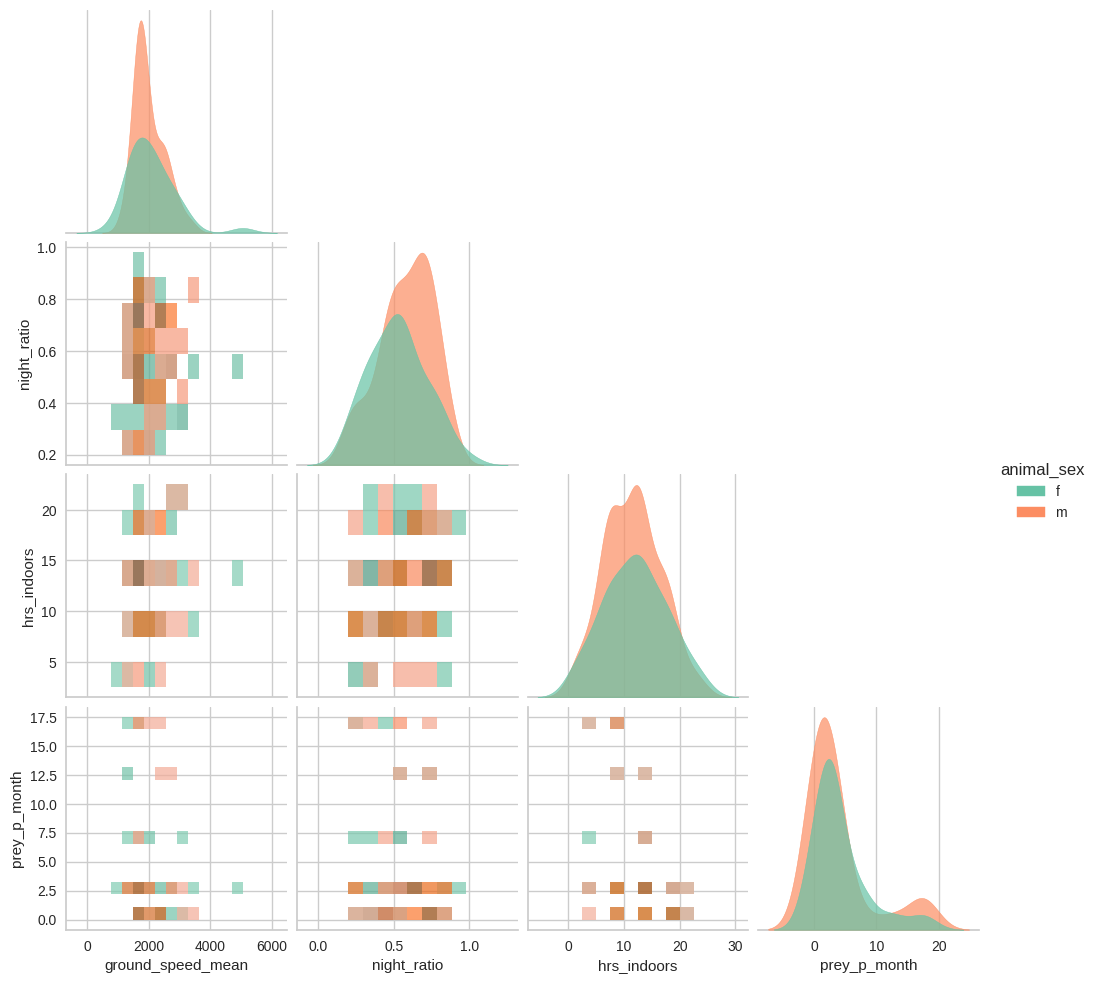

In [54]:
q3_vars = [
    "ground_speed_mean",
    "night_ratio",
    "hrs_indoors",
    "prey_p_month"
]

q3_vars = [v for v in q3_vars]

sns.pairplot(
    cat_level[q3_vars + ["animal_sex"]],
    hue="animal_sex",
    kind="hist",
    diag_kind="kde",
    corner=True,
    palette="Set2",
    plot_kws={'alpha': 0.7},
    diag_kws={'alpha': 0.7}
)


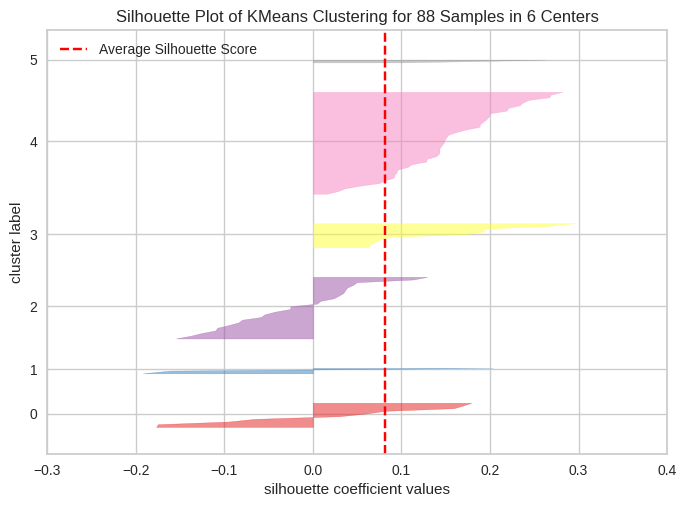

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 88 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [55]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(q3_best_k, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)
visualizer.show()

## M4 Update

### Baseline Replication


In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

BASE_K = q3_best_k

km_base = KMeans(n_clusters=BASE_K, random_state=42, n_init=20)
labels_base = km_base.fit_predict(X_scaled)

cat_level["cluster_base"] = labels_base

sil_base = silhouette_score(X_scaled, labels_base)
print("Baseline KMeans | K =", BASE_K, "| silhouette =", round(sil_base, 4))
cat_level["cluster_base"].value_counts().sort_index()


Baseline KMeans | K = 6 | silhouette = 0.189


,count
cluster_base,
0,21
1,43
2,9
3,10
4,3
5,2


In [57]:
from scipy.stats import chi2_contingency

def sex_cluster_assoc(sex_series, cluster_series):
    ct = pd.crosstab(sex_series, cluster_series)
    chi2, p, dof, exp = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    cramers_v = np.sqrt((chi2/n) / (min(r-1, k-1) + 1e-12))
    return ct, (ct.div(ct.sum(axis=1), axis=0)), cramers_v, p

ct_base, ct_base_norm, v_base, p_base = sex_cluster_assoc(cat_level["animal_sex"], cat_level["cluster_base"])
display(ct_base)
display(ct_base_norm.round(3))
print("Cramer's V (baseline) =", round(v_base,3), "| p-value =", p_base)


cluster_base,0,1,2,3,4,5
animal_sex,,,,,,
f,10,16,4,5,2,1
m,11,27,5,5,1,1


cluster_base,0,1,2,3,4,5
animal_sex,,,,,,
f,0.263,0.421,0.105,0.132,0.053,0.026
m,0.220,0.540,0.100,0.100,0.020,0.020


Cramer's V (baseline) = 0.139 | p-value = 0.8887373424126769


### Refinement：Stability

In [58]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

seeds = list(range(10, 60, 5))
rows = []

for s in seeds:
    km = KMeans(n_clusters=BASE_K, random_state=s, n_init=20)
    lab = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, lab)
    ari = adjusted_rand_score(labels_base, lab)

    ct, ct_norm, v, p = sex_cluster_assoc(cat_level["animal_sex"], lab)

    rows.append({
        "seed": s,
        "silhouette": sil,
        "ARI_vs_baseline": ari,
        "cramers_v": v,
        "p_value": p
    })

stability_df = pd.DataFrame(rows)
display(stability_df)

print("Silhouette range:", round(stability_df["silhouette"].min(),3), "-", round(stability_df["silhouette"].max(),3))
print("ARI range:", round(stability_df["ARI_vs_baseline"].min(),3), "-", round(stability_df["ARI_vs_baseline"].max(),3))
print("Cramer's V range:", round(stability_df["cramers_v"].min(),3), "-", round(stability_df["cramers_v"].max(),3))
print("p-value range:", round(stability_df["p_value"].min(),3), "-", round(stability_df["p_value"].max(),3))


,seed,silhouette,ARI_vs_baseline,cramers_v,p_value
0,10,0.186496,0.826295,0.210501,0.563997
1,15,0.184369,0.975076,0.211644,0.557826
2,20,0.183432,0.910659,0.123983,0.929415
3,25,0.179652,0.827889,0.203592,0.601184
4,30,0.183966,0.876115,0.233010,0.443590
5,35,0.183578,0.936200,0.195451,0.644411
6,40,0.185045,0.926143,0.125988,0.924660
7,45,0.192026,0.913739,0.162022,0.804782
8,50,0.178146,0.920413,0.196791,0.637358
9,55,0.189167,0.949454,0.142953,0.876286


Silhouette range: 0.178 - 0.192
ARI range: 0.826 - 0.975
Cramer's V range: 0.124 - 0.233
p-value range: 0.444 - 0.929


### Method Upgrade：PCA-space clustering

In [59]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("PCA dims =", X_pca.shape[1], "| explained variance =", round(pca.explained_variance_ratio_.sum(),3))

km_pca = KMeans(n_clusters=BASE_K, random_state=42, n_init=20)
labels_pca = km_pca.fit_predict(X_pca)

cat_level["cluster_pca"] = labels_pca

sil_pca = silhouette_score(X_pca, labels_pca)
print("Silhouette | baseline space:", round(sil_base,4), "| PCA space:", round(sil_pca,4))
print("ARI (baseline labels vs PCA labels):", round(adjusted_rand_score(labels_base, labels_pca), 3))


PCA dims = 9 | explained variance = 0.913
Silhouette | baseline space: 0.189 | PCA space: 0.1868
ARI (baseline labels vs PCA labels): 0.743


In [60]:
ct_pca, ct_pca_norm, v_pca, p_pca = sex_cluster_assoc(cat_level["animal_sex"], cat_level["cluster_pca"])
display(ct_pca_norm.round(3))
print("Cramer's V (PCA clusters) =", round(v_pca,3), "| p-value =", p_pca)


cluster_pca,0,1,2,3,4,5
animal_sex,,,,,,
f,0.395,0.158,0.184,0.053,0.026,0.184
m,0.480,0.160,0.220,0.000,0.020,0.120


Cramer's V (PCA clusters) = 0.207 | p-value = 0.5841590123214707


### Q3-B: Within-cluster behavioral differences

In [61]:
from scipy.stats import mannwhitneyu

behavior_vars = ["hrs_indoors", "prey_p_month", "night_ratio", "ground_speed_mean"]
behavior_vars = [v for v in behavior_vars if v in cat_level.columns]

rows = []
for cl in sorted(cat_level["cluster_base"].unique()):
    sub = cat_level[cat_level["cluster_base"] == cl]
    for var in behavior_vars:
        male = sub[sub["animal_sex"] == "m"][var].dropna()
        female = sub[sub["animal_sex"] == "f"][var].dropna()

        if len(male) < 5 or len(female) < 5:
            rows.append({"cluster": cl, "var": var, "male_n": len(male), "female_n": len(female),
                         "p_value": np.nan, "male_median": male.median() if len(male) else np.nan,
                         "female_median": female.median() if len(female) else np.nan})
            continue

        stat, p = mannwhitneyu(male, female, alternative="two-sided")
        rows.append({"cluster": cl, "var": var, "male_n": len(male), "female_n": len(female),
                     "male_median": male.median(), "female_median": female.median(), "p_value": p})

within_base = pd.DataFrame(rows).sort_values(["var","cluster"])
display(within_base)



,cluster,var,male_n,female_n,male_median,female_median,p_value
3,0,ground_speed_mean,11,10,1791.666667,1885.205800,0.647156
7,1,ground_speed_mean,27,16,1781.783133,2041.825464,0.660151
11,2,ground_speed_mean,5,4,2758.623853,2856.720911,NaN
15,3,ground_speed_mean,5,5,1670.079208,1303.263158,0.055556
19,4,ground_speed_mean,1,2,2913.000000,2859.369082,NaN
23,5,ground_speed_mean,1,1,2541.568966,1367.862069,NaN
0,0,hrs_indoors,11,10,12.500000,12.500000,0.680464
4,1,hrs_indoors,27,16,12.500000,12.500000,0.936732
8,2,hrs_indoors,5,4,12.500000,17.500000,NaN
12,3,hrs_indoors,5,5,7.500000,2.500000,0.563703


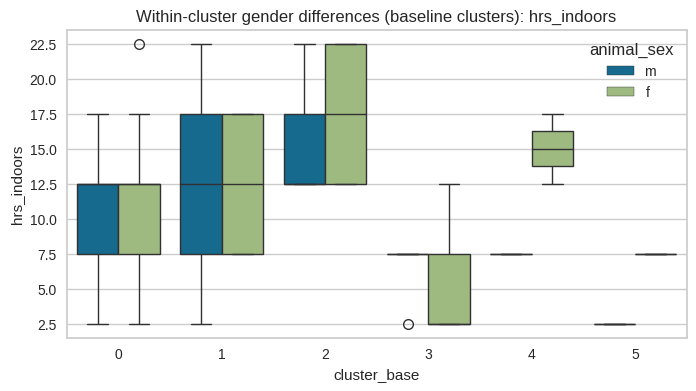

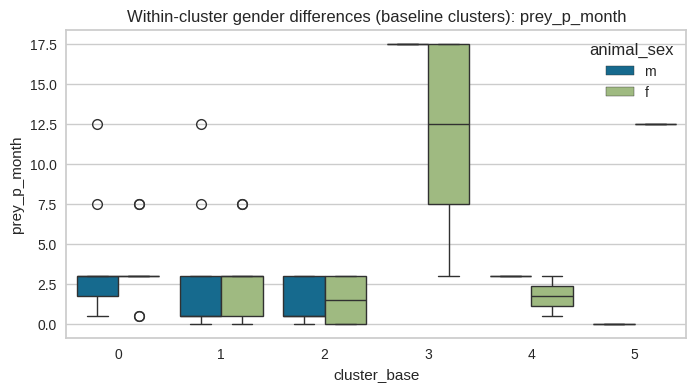

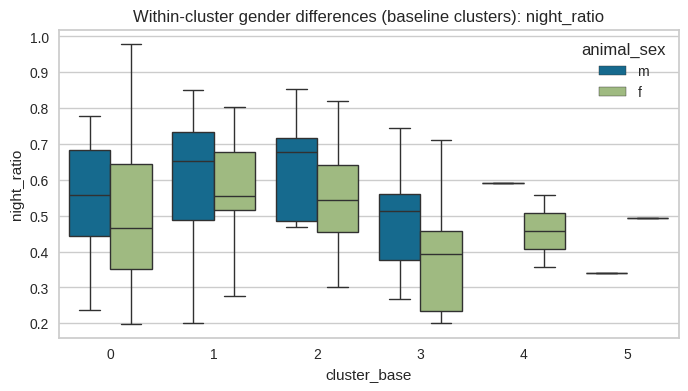

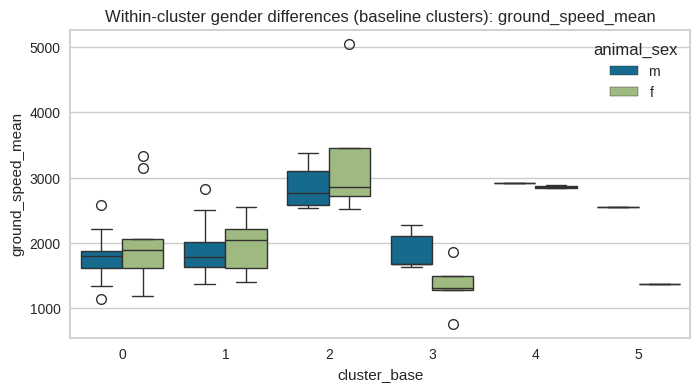

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

for var in behavior_vars:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=cat_level, x="cluster_base", y=var, hue="animal_sex")
    plt.title(f"Within-cluster gender differences (baseline clusters): {var}")
    plt.show()


In [63]:
from scipy.stats import mannwhitneyu

behavior_vars = ["hrs_indoors", "prey_p_month", "night_ratio", "ground_speed_mean"]
behavior_vars = [v for v in behavior_vars if v in cat_level.columns]

rows = []
for cl in sorted(cat_level["cluster_pca"].unique()):
    sub = cat_level[cat_level["cluster_pca"] == cl]
    for var in behavior_vars:
        male = sub[sub["animal_sex"] == "m"][var].dropna()
        female = sub[sub["animal_sex"] == "f"][var].dropna()

        if len(male) < 5 or len(female) < 5:
            rows.append({"cluster": cl, "var": var, "male_n": len(male), "female_n": len(female),
                         "p_value": np.nan, "male_median": male.median() if len(male) else np.nan,
                         "female_median": female.median() if len(female) else np.nan})
            continue

        stat, p = mannwhitneyu(male, female, alternative="two-sided")
        rows.append({"cluster": cl, "var": var, "male_n": len(male), "female_n": len(female),
                     "male_median": male.median(), "female_median": female.median(), "p_value": p})

within_pca = pd.DataFrame(rows).sort_values(["var","cluster"])
display(within_pca)



,cluster,var,male_n,female_n,male_median,female_median,p_value
3,0,ground_speed_mean,24,15,1763.817186,1960.758621,0.553995
7,1,ground_speed_mean,8,6,2792.841338,2856.720911,0.851815
11,2,ground_speed_mean,11,7,1791.666667,1759.024390,0.425151
15,3,ground_speed_mean,0,2,NaN,2859.369082,NaN
19,4,ground_speed_mean,1,1,2541.568966,1367.862069,NaN
23,5,ground_speed_mean,6,7,1645.881481,1494.113780,0.445221
0,0,hrs_indoors,24,15,12.500000,12.500000,0.383723
4,1,hrs_indoors,8,6,15.000000,12.500000,0.638142
8,2,hrs_indoors,11,7,12.500000,12.500000,0.315572
12,3,hrs_indoors,0,2,NaN,15.000000,NaN


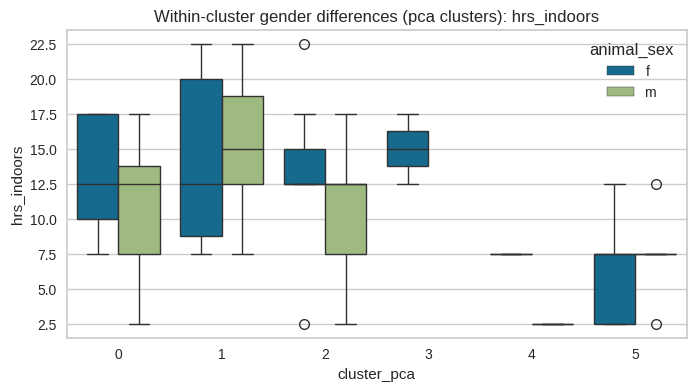

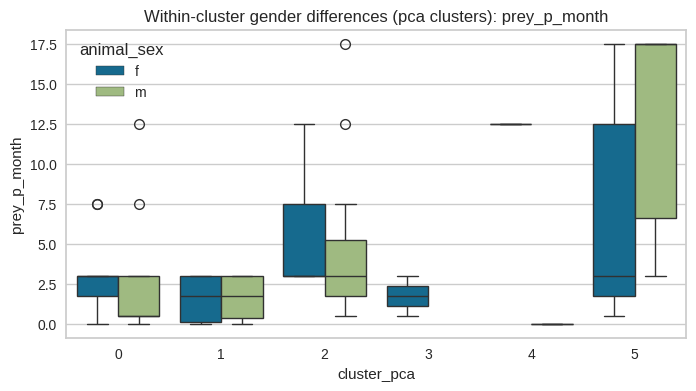

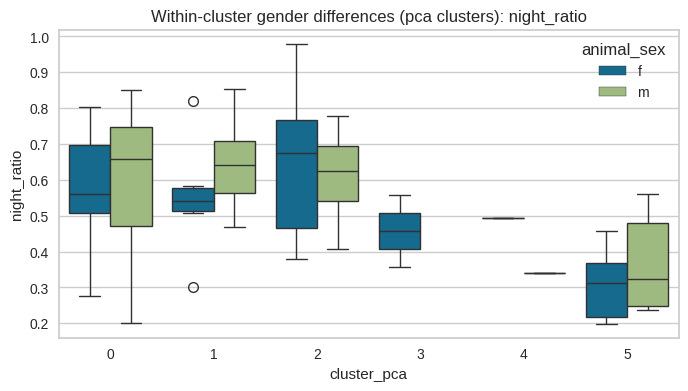

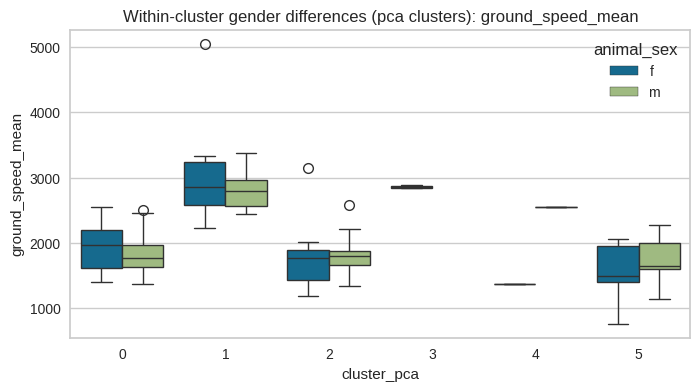

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

for var in behavior_vars:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=cat_level, x="cluster_pca", y=var, hue="animal_sex")
    plt.title(f"Within-cluster gender differences (pca clusters): {var}")
    plt.show()


### Comparison Conclusion Table

In [65]:
summary = pd.DataFrame([
    {"setting": "Baseline (orig space)", "silhouette": sil_base, "cramers_v": v_base, "p_value": p_base},
    {"setting": "PCA space", "silhouette": sil_pca, "cramers_v": v_pca, "p_value": p_pca},
    {"setting": "Seed stability (mean)", "silhouette": stability_df["silhouette"].mean() if "stability_df" in globals() else np.nan,
     "cramers_v": v_stability["cramers_v"].mean() if "v_stability" in globals() else np.nan, "p_value": np.nan}
])
display(summary.round(4))


,setting,silhouette,cramers_v,p_value
0,Baseline (orig space),0.1890,0.1390,0.8887
1,PCA space,0.1868,0.2068,0.5842
2,Seed stability (mean),0.1846,0.1806,NaN


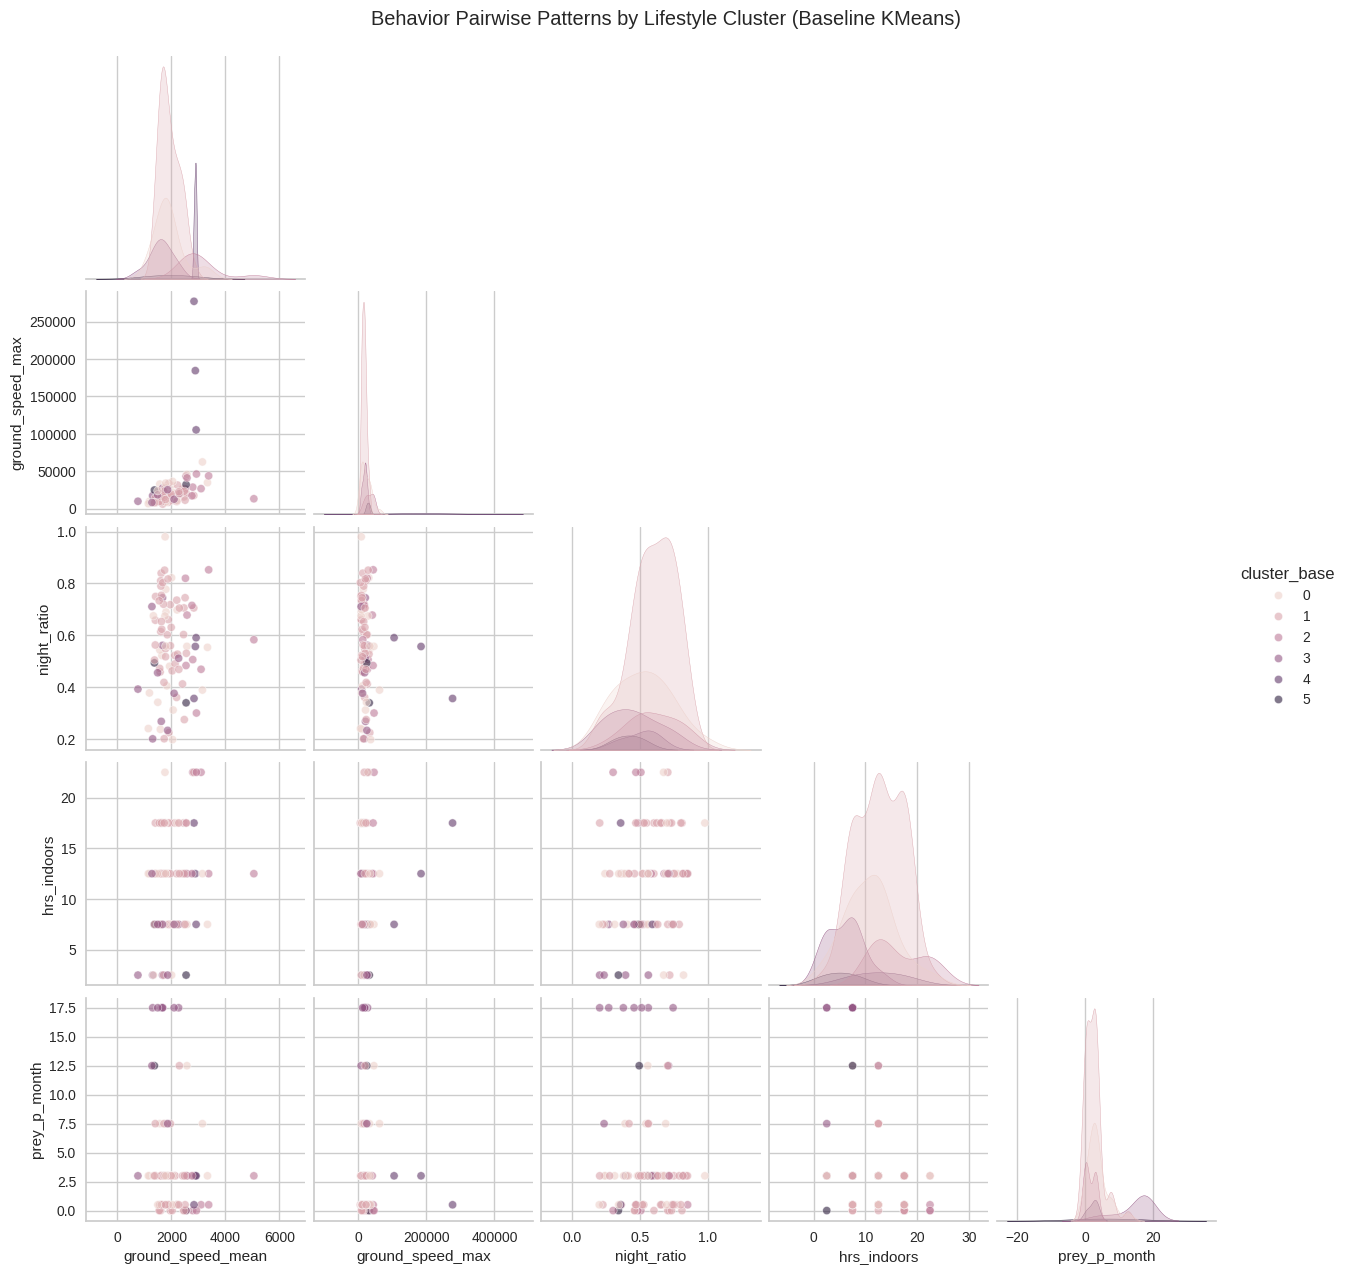

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

vars_ = ["ground_speed_mean","ground_speed_max","night_ratio","hrs_indoors","prey_p_month"]
vars_ = [v for v in vars_ if v in cat_level.columns]

plot_df = cat_level[vars_ + ["cluster_base"]].dropna()

g = sns.pairplot(
    plot_df,
    vars=vars_,
    hue="cluster_base",
    corner=True,
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 35}
)
g.fig.suptitle("Behavior Pairwise Patterns by Lifestyle Cluster (Baseline KMeans)", y=1.02)
plt.show()


## AI Disclosure





*   Add Comments
*   Coding Aid (part)
*   Text Revision
*   Grammar Check
*   Project Initial Brainstorm
*   Formatting




ChatGPT Link:
https://chatgpt.com/share/699d1d91-8f84-800e-8e6c-60d7a4d3de04





Github Link: https://github.com/Nanase1994/BA820-Unsupervised-and-Unstructured-Machine-Learning-Project-/blob/main/M3_Integrated.ipynb